# Assignment 6: Implement a Feedforward Neural Network and Backpropagation

**Dataset:** Breast Cancer Wisconsin Diagnostic dataset from Scikit-learn  
**Task type:** Binary classification  
**Required architecture:** $30 \rightarrow 16 \rightarrow 1$  
**Hidden activation:** ReLU  
**Output activation:** Sigmoid  
**Loss:** Binary cross-entropy  
**Optimizer:** Full-batch gradient descent  
**Total marks:** 20

The positive label is `1` (benign) in the original Scikit-learn dataset. State this clearly when interpreting precision and recall.

## Assignment rules

1. Use NumPy for Tasks 3–8;
2. Use a fixed random state so that results are reproducible.
3. Fit preprocessing only on the training data.
4. Use validation data for model decisions and use the test set only for final evaluation.
5. Keep every output visible in the submitted notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Task 1 — Load the Breast Cancer dataset and print its shape, feature names, target names, and class counts. **[1 mark]**

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Task 1 solution
# Write your code here.
X = df.drop("target", axis=1)
y = df["target"]

print("Shape of features:", X.shape)
print("Shape of target:", y.shape)
print("\nFeatures:", data.feature_names)
print("\nTargets:", data.target_names)

classes, count = np.unique(y, return_counts=True)
print("\nClass\tCount")
for cls, cnt in zip(classes, count):
    print(cls, "\t", cnt)

Shape of features: (569, 30)
Shape of target: (569,)

Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Targets: ['malignant' 'benign']

Class	Count
0 	 212
1 	 357


## Task 2 — Create a stratified 70/15/15 split and standardize all features using statistics learned only from the training set. **[2 marks]**

In [4]:
# Task 2 solution
# Write your code here.
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Perform stratified 70:15:15 dataset split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Shape of training dataset: X =", X_train.shape,"y =", y_train.shape)
print("Shape of validation dataset: X =", X_val.shape,"y =", y_val.shape)
print("Shape of testing dataset: X =", X_test.shape,"y =", y_test.shape)

Shape of training dataset: X = (398, 30) y = (398,)
Shape of validation dataset: X = (85, 30) y = (85,)
Shape of testing dataset: X = (86, 30) y = (86,)


## Task 3 — Implement stable sigmoid, ReLU, and ReLU-derivative functions using NumPy. **[2 marks]**

**Activation Functions**

The sigmoid activation is used for the output layer:
$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$
Its derivative is:
$$
\sigma'(z) = \sigma(z)(1-\sigma(z))
$$

The ReLU activation is used for the hidden layer:
$$
\text{ReLU}(z) = \max(0,z)
$$
Its derivative is:
$$
\text{ReLU}'(z) =
\begin{cases}
1, & z>0\\
0, & z\leq0
\end{cases}
$$

In [5]:
# Task 3 solution
# Write your code here.
def sigmoid(z):
    z = np.clip(z, -500, 500)       # prevent numerical overflow
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(z):
    a = sigmoid(z)
    return a * (1.0 - a)

def relu(z):
    return np.maximum(0.0, z)

def relu_derivative(z):
    return np.astype(z > 0.0, np.float32)

# Test the functions
arr = np.array([-2, -1, 0, 1, 2])
print("Input:", arr)
print("Sigmoid:", sigmoid(arr))
print("Sigmoid derivative:", sigmoid_derivative(arr))
print("ReLU:", relu(arr))
print("ReLU derivative:", relu_derivative(arr))

Input: [-2 -1  0  1  2]
Sigmoid: [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
Sigmoid derivative: [0.10499359 0.19661193 0.25       0.19661193 0.10499359]
ReLU: [0. 0. 0. 1. 2.]
ReLU derivative: [0. 0. 0. 1. 1.]


## Task 4 — Initialize the parameters of a $30 \rightarrow 16 \rightarrow 1$ neural network using He initialization and print the shape of each parameter. **[2 marks]**

**He Initialization**

He initialization is used to initialize the weights of layers with **ReLU activation**. It draws weights from a zero-mean Gaussian distribution with variance:
$$
W \sim \mathcal{N}\left(0,\frac{2}{n_{in}}\right)
$$
where \($n_{in}$\) is the number of input neurons. Thus, the standard deviation is:
$$
\sigma = \sqrt{\frac{2}{n_{in}}}
$$
He initialization helps maintain a suitable variance of activations and gradients when using ReLU.

In [6]:
# Task 4 solution
# Write your code here.
W1 = np.random.randn(30, 16) * np.sqrt(2 / 30)
b1 = np.zeros((1, 16))
W2 = np.random.randn(16, 1) * np.sqrt(2 / 16)
b2 = np.zeros((1, 1))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (30, 16)
b1 shape: (1, 16)
W2 shape: (16, 1)
b2 shape: (1, 1)


## Task 5 — Implement forward propagation and print the shapes of $Z^{[1]}$, $A^{[1]}$, $Z^{[2]}$, and $A^{[2]}$ for five samples. **[3 marks]**

**Forward Propagation**

For forward propagation, compute the hidden-layer pre-activation and activation followed by the output-layer pre-activation and sigmoid activation:
$$
Z^{[1]} = XW^{[1]} + b^{[1]}, \qquad A^{[1]} = \text{ReLU}(Z^{[1]})
$$
$$
Z^{[2]} = A^{[1]}W^{[2]} + b^{[2]}, \qquad A^{[2]} = \sigma(Z^{[2]})
$$

In [7]:
# Task 5 solution
# Write your code here.
def forward_propagation(X):
    """
    Foward pass in Feed-forward NN
    """
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    
    return Z1, A1, Z2, A2

# Forward propagation for 5 samples
Z1, A1, Z2, A2 = forward_propagation(X_train[:5])
print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)
print("Z2 shape:", Z2.shape)
print("A2 shape:", A2.shape)

Z1 shape: (5, 16)
A1 shape: (5, 16)
Z2 shape: (5, 1)
A2 shape: (5, 1)


## Task 6 — Implement binary cross-entropy and calculate the initial training loss. **[1 mark]**

**Binary Cross-Entropy Loss**

For binary classification, the binary cross-entropy loss is:
$$
L = -\frac{1}{m}\sum_{i=1}^{m}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$
where \($m$\) is the number of training samples, \($y_i$\) is the true label, and \($\hat{y}_i=A_i^{[2]}$\) is the predicted probability.

In [8]:
# Task 6 solution
# Write your code here.
def binary_cross_entropy(y_true, y_pred):
    y_true = y_true.to_numpy().reshape(-1, 1)
    y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Calculate initial training loss
Z1, A1, Z2, A2 = forward_propagation(X_train)
initial_loss = binary_cross_entropy(y_train, A2)
print("Initial training loss:", initial_loss)

Initial training loss: 0.4994363035182772


## Task 7 — Implement backpropagation for $dW^{[2]}$, $db^{[2]}$, $dW^{[1]}$, and $db^{[1]}$, then print all gradient shapes. **[4 marks]**

**Backpropagation**

For sigmoid output with binary cross-entropy:
$$
dZ^{[2]} = A^{[2]} - y
$$
Then:
$$
dW^{[2]} = \frac{1}{m}(A^{[1]})^T dZ^{[2]}, \qquad
db^{[2]} = \frac{1}{m}\sum dZ^{[2]}
$$
$$
dZ^{[1]} =
\left(dZ^{[2]}(W^{[2]})^T\right)
\odot \text{ReLU}'(Z^{[1]})
$$
$$
dW^{[1]} = \frac{1}{m}X^T dZ^{[1]}, \qquad
db^{[1]} = \frac{1}{m}\sum dZ^{[1]}
$$

In [9]:
# Task 7 solution
# Write your code here.
def backward_propagation(X, y, Z1, A1, Z2, A2):
    """
    Backward pass in a Feed-forward NN
    """
    m = X.shape[0]
    y = y.to_numpy().reshape(-1, 1)
    
    dZ2 = A2 - y
    dW2 = (A1.T @ dZ2) / m
    db2 = np.mean(dZ2, axis=0, keepdims=True)
    
    dZ1 = (dZ2 @ W2.T) * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)
    
    return dW2, db2, dW1, db1

# Perform backpropagation on initial forward pass
dW2, db2, dW1, db1 = backward_propagation(X_train, y_train, Z1, A1, Z2, A2)
print("dW2 shape:", dW2.shape)
print("db2 shape:", db2.shape)
print("dW1 shape:", dW1.shape)
print("db1 shape:", db1.shape)

dW2 shape: (16, 1)
db2 shape: (1, 1)
dW1 shape: (30, 16)
db1 shape: (1, 16)


## Task 8 — Train the network for at least 2,000 epochs with gradient descent and plot training and validation loss. **[2 marks]**

Final training loss: 0.06306567527838342
Final validation loss: 0.06456198413777806


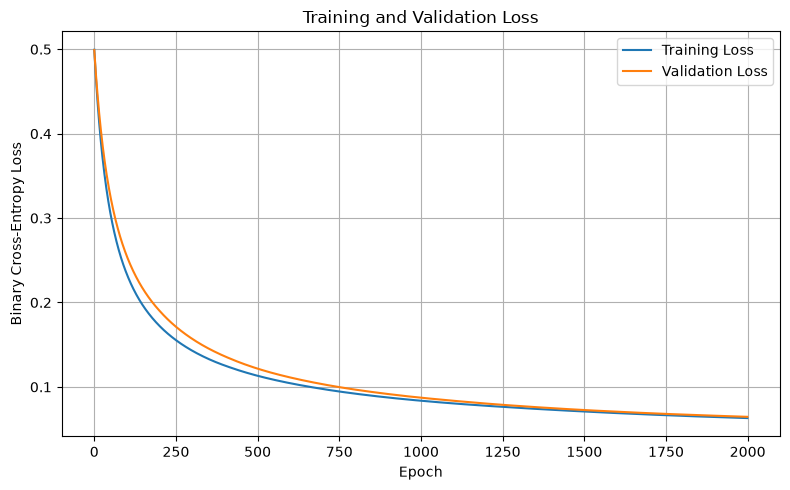

In [10]:
# Task 8 solution
# Write your code here.
epochs = 2000
learning_rate = 0.01

train_losses = []
val_losses = []

for epoch in range(epochs):
    Z1, A1, Z2, A2 = forward_propagation(X_train)
    
    train_loss = binary_cross_entropy(y_train, A2)
    train_losses.append(train_loss)
    
    dW2, db2, dW1, db1 = backward_propagation(X_train, y_train, Z1, A1, Z2, A2)
    
    # Gradient descent update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    
    _, _, _, A2_val = forward_propagation(X_val)
    val_loss = binary_cross_entropy(y_val, A2_val)
    val_losses.append(val_loss)
    
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/train_vs_val.png")

print("Final training loss:", train_losses[-1])
print("Final validation loss:", val_losses[-1])

## Task 9 — Evaluate the final test set using accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and a confusion matrix. **[2 marks]**

In [11]:
# Task 9 solution
# Write your code here.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# Final test predictions
_, _, _, A2_test = forward_propagation(X_test)

# Convert probabilities to class predictions
y_pred_prob = A2_test.ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)
y_true = y_test.to_numpy()

# Evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_prob)
pr_auc = average_precision_score(y_true, y_pred_prob)
cm = confusion_matrix(y_true, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)
print("PR-AUC   :", pr_auc)

print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.9651162790697675
Precision: 0.9811320754716981
Recall   : 0.9629629629629629
F1-score : 0.9719626168224299
ROC-AUC  : 0.9936342592592593
PR-AUC   : 0.9959095126185742

Confusion Matrix:
[[31  1]
 [ 2 52]]


## Task 10 — Compare the NumPy network with Scikit-learn `MLPClassifier` in one result table and write two observations. **[1 mark]**

In [12]:
# Task 10 solution
# Write your code here.
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="sgd",
    learning_rate_init=0.01,
    max_iter=2000,
    random_state=RANDOM_SEED
)
mlp.fit(X_train, y_train)

# Scikit-learn predictions
sklearn_prob = mlp.predict_proba(X_test)[:, 1]
sklearn_pred = mlp.predict(X_test)

# Calculate metrics
results = pd.DataFrame({
    "Model": ["NumPy Network", "MLPClassifier"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, sklearn_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, sklearn_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, sklearn_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, sklearn_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_prob),
        roc_auc_score(y_test, sklearn_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_pred_prob),
        average_precision_score(y_test, sklearn_prob)
    ]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,NumPy Network,0.9651,0.9811,0.963,0.972,0.9936,0.9959
1,MLPClassifier,0.9651,0.9811,0.963,0.972,0.9902,0.9937


**Observations**

1. Both models achieve ***identical Accuracy, Precision, Recall, and F1-score***, showing comparable classification performance on the test set.
2. The `NumPy network` ***performs slightly better on ranking-based metrics***, with higher ROC-AUC and PR-AUC than `MLPClassifier`.

## Marks distribution

| Task | Component | Marks |
|---:|---|---:|
| 1 | Dataset inspection | 1 |
| 2 | Leakage-free split and standardization | 2 |
| 3 | Activation functions | 2 |
| 4 | Parameter initialization | 2 |
| 5 | Forward propagation | 3 |
| 6 | Binary cross-entropy | 1 |
| 7 | Backpropagation | 4 |
| 8 | Training and learning curves | 2 |
| 9 | Test evaluation | 2 |
| 10 | Scikit-learn comparison and observations | 1 |
|  | **Total** | **20** |

---
End of the assignment